# TinyChirp CNN-Time TensorFlow

Train a 1D CNN on raw audio waveforms (no spectrogram), export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/tinychirp_cnn.ipynb` but replaces the 2D mel CNN with a 1D time CNN similar to `StreamingCNNArch` from the TinyChirp `CNN_Time` model.

In [6]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [8]:
from typing import TYPE_CHECKING

from building_tensorflow.utils import (

    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("cnn_time_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs
BATCH_SIZE = 32

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)

Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/cnn_time_tf.tflite


In [9]:
from building_tensorflow.utils import make_time_datasets, get_flops_native

train_ds, val_ds, test_ds, label_names= make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print("Steps per epoch (train, val, test):")

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
Steps per epoch (train, val, test):


In [10]:
model = keras.Sequential([
    keras.layers.Input(shape=(TARGET_AUDIO_LEN_TIME, 1)),
    keras.layers.Conv1D(4, 3, activation="relu"),
    keras.layers.MaxPooling1D(pool_size=2, strides=2),
    keras.layers.Conv1D(8, 3, activation="relu"),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(num_labels),
])


model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()
get_flops_native(model, batch_size=1)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 47870, 4)       │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 23935, 4)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 23933, 8)       │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826 (3.23 KB)

 Trainable params: 826 (3.23 KB)

 Non-trainable params: 0 (0.00 B)

/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_7
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-16 15:42:02.954139: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-16 15:42:02.955055: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-16 15:42:02.955124: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-16 15:42:02.955450: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful N

6511250

In [ ]:
from building_tensorflow.utils import init_wandb, get_callbacks, finish_wandb

init_wandb("cnn_time", config={
    "conv1_filters": 4,
    "conv2_filters": 8,
    "kernel_size": 3,
    "dense_units": 64,
})

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=50,
    callbacks=get_callbacks(10,5, BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.


wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776346926.829892   14092 service.cc:145] XLA service 0x7d686c006990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776346926.829927   14092 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-16 15:42:06.883568: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-16 15:42:07.162077: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


  3/353 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.6441 - loss: 0.6901

I0000 00:00:1776346932.917547   14092 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6698 - loss: 0.6267

/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


353/353 ━━━━━━━━━━━━━━━━━━━━ 34s 76ms/step - accuracy: 0.6821 - loss: 0.5769 - val_accuracy: 0.7420 - val_loss: 0.4556
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.8032 - loss: 0.4141 - val_accuracy: 0.8732 - val_loss: 0.3428
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8479 - loss: 0.3500 - val_accuracy: 0.9159 - val_loss: 0.2980
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.8666 - loss: 0.3290 - val_accuracy: 0.8848 - val_loss: 0.2851
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8828 - loss: 0.3064 - val_accuracy: 0.8920 - val_loss: 0.2606
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8907 - loss: 0.2910 - val_accuracy: 0.8964 - val_loss: 0.2461
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.8973 - loss: 0.2793 - val_accuracy: 0.9246 - val_loss: 0.2338
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.9042 - loss: 0.2681 - val_

353it [00:18, 20.24it/s]2026-04-14 19:00:43.406726: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
353it [00:18, 18.62it/s]
43it [00:02, 17.77it/s]2026-04-14 19:00:46.217663: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:02, 17.89it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.2354  (best F2 threshold)
Accuracy : 0.9261
Precision: 0.8221
Recall   : 0.9891
F2 score : 0.9505
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9784


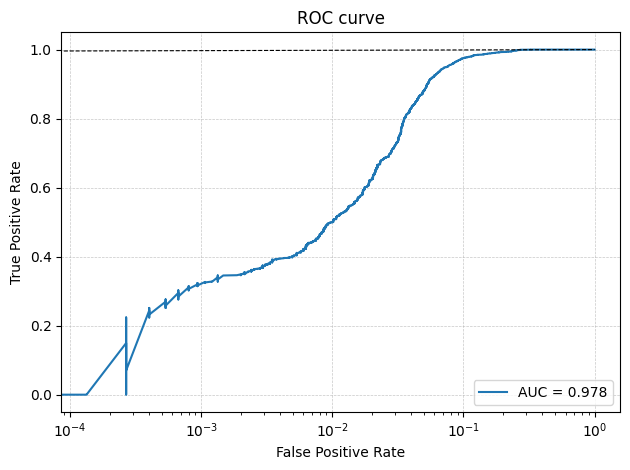

In [ ]:
from building_tensorflow.utils import evaluate_binary_classifier, display_eval_metrics

train_metrics, test_metrics = evaluate_binary_classifier(model, train_ds, test_ds)
display_eval_metrics(train_metrics, test_metrics)

In [ ]:
from building_tensorflow.utils import (
    TARGET_AUDIO_LEN_TIME,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

val_specs = build_representative_batches(test_ds, TARGET_AUDIO_LEN_TIME, take=100)

export_keras_model_to_int8_tflite(model, val_specs, OUT_TFLITE)

INFO:tensorflow:Assets written to: temp_saved_model/assets


2026-04-14 19:00:46.934710: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
INFO:tensorflow:Assets written to: temp_saved_model/assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  131045838045776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131043868998320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131048611673216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131048611672864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131048611672160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131048611671104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131048611671632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131048611673920: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1776186047.182321    5602 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776186047.182337    5602 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-14 19:00:47.182492: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-14 19:00:47.182873: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-14 19:00:47.182882: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-14 19:00:47.188509: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-14 19:00:47.211849: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: temp_saved_model
2026-04-14 19:00:47.219822: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 37331 microseconds.


Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/cnn_time_tf.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [ ]:
from building_tensorflow.utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, "cnn_time_tf", train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")